In [9]:
import os
import sys
sys.path.append(os.path.expanduser('~'))
#general
import time
import numba as nb
import numpy as np 
import json
import importlib
from matplotlib import pyplot as plt
from datetime import datetime as dt
#scipy
from scipy.ndimage import median_filter 
from scipy.optimize import minimize,check_grad,least_squares
#astropy
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from astropy.time import Time
#in-house
from albatros_analysis.src.correlations import baseband_data_classes as bdc
from albatros_analysis.src.utils import baseband_utils as butils
from albatros_analysis.src.utils import orbcomm_utils as outils
import helper_finetiming as hf
#import coord

In [ ]:
#=================================================
#visibility stuff
#=================================================
@nb.njit(parallel=True)
def apply_delay(arr, out, delay, freqs):
    # apply delay to an array of complex electric field or their correlation
    # does exp( j 2 pi nu tau) sign of tau is user dependent
    # freqs should correspond to the columns of the nspec x nchan array
    nspec = arr.shape[0]
    nchan = arr.shape[1]
    for i in nb.prange(nspec):
        for j in range(nchan):
            out[i, j] = arr[i, j] * np.exp(2j * np.pi * freqs[j] * delay[i])
    return out

@nb.njit(parallel=True)
def xcorr_avg(arr1,arr2,acclen):
    #helper function
    nblocks = arr1.shape[0]//acclen
    nchan = arr1.shape[1]
    out = np.zeros((nblocks,nchan),dtype=arr1.dtype)
    for i in nb.prange(nblocks):
        for j in range(acclen):
            for k in range(nchan):
                out[i,k] += arr1[i*acclen + j,k]*np.conj(arr2[i*acclen + j,k])
        out[i,:]/=acclen
    return out

def get_vis(spec1_p0, spec1_p1, spec2_p0, spec2_p1, delay_tot, freqs, acclen):
    spec2_phased = np.empty_like(spec2_p0)
    spec2_phased = apply_delay(spec2_p0, spec2_phased, -delay_tot, freqs)
    Vxx = xcorr_avg(spec1_p0,spec2_phased,acclen)
    spec2_phased = np.empty_like(spec2_p0)
    spec2_phased = apply_delay(spec2_p1, spec2_phased, -delay_tot, freqs)
    Vyy = xcorr_avg(spec1_p1,spec2_phased,acclen)
    return (Vxx+Vyy)/2

In [ ]:
#=================================================
#geometry and coordinates
#=================================================
def get_all_bls(coords,ants):
    #ant0 is always the refant for ENU coord sys
    nant=len(ants)
    nbl=0
    bls=[]
    for i in range(nant):
        for j in range(i+1,nant):
            coords1 = coords[ants[i]]
            coords2 = coords[ants[j]]
            xyz1=EarthLocation.from_geodetic(lat=coords1[0], lon=coords1[1], height=coords1[2]).itrs.cartesian.xyz.to_value()
            xyz2=EarthLocation.from_geodetic(lat=coords2[0], lon=coords2[1], height=coords2[2]).itrs.cartesian.xyz.to_value()
            bls.append(xyz2-xyz1)
    bls=np.asarray(bls)
    print(bls.shape)
    bls=coord.itrs_to_enu(bls,coords[0][0],coords[0][1])
    return bls

def get_geo_delay(bl,alt,az):
    x = 0
    c=299792458
    x = np.sin(az)*np.cos(alt) * bl[0] #east
    x += np.cos(az)*np.cos(alt) * bl[1] #north
    x += np.sin(alt) * bl[2] #up
    # print(x)
    return x/c

In [ ]:
#config and setup
with open("/home/mohanagr/albatros_analysis/scripts/xcorr/config/config_gpu_7ant_jul22_satpulse.json") as f:
    config = json.load(f)
antpos=[]
for i, (ant, details) in enumerate(config["antennas"].items()):
        antpos.append(details["coordinates"])
print(antpos)

PermissionError: [Errno 13] Permission denied: '/home/mohanagr/albatros_analysis/scripts/xcorr/config/config_gpu_7ant_jul22_satpulse.json'

In [21]:
T_SPECTRA = 4096/250e6 * 64
print('T_SPECTRA:', T_SPECTRA)
CHANSIZE = 1/T_SPECTRA
print('CHANSIZE:', CHANSIZE)
acclen = 1024
print('acclen:', acclen)
ts_pulse_start=1753216695
print('start ts', ts_pulse_start)
ts_pulse_end=1753216960
print('end ts', ts_pulse_end)

T_SPECTRA: 0.001048576
CHANSIZE: 953.6743164062499
acclen: 1024
start ts 1753216695
end ts 1753216960


In [ ]:
#=================================================
#load in clock delay
#=================================================

clock_delay_new = np.load("delay_solution_marsall_non_linear.npy")
# clock_delay_new = np.asarray([-21456.04569358,   7866.94280902,  -3615.90216717,  -4132.93311918,
#     8439.06568661])
clock_delay = np.load("delay_solution_mars57.npy") #old delay for one baseline
print(clock_delay.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'delay_solution_marsall_non_linear.npy'

In [ ]:
#=================================================
#load in timing discrepancy
#=================================================

#get m and c

raw data for 3 minutes for 20 MHz and 28 MHz bands

In [77]:
# sky_data = np.load("/scratch/thomasb/mohan/raw_ant=7_pol=2_cha=360:392_20251219T140210/raw_1753216695:1753216960_bit=1_ant=7_pol=2_cha=360:392_tim=246_upx=64_acc=1024_ipfb=0.2_complex64_regular_20251219T140210.npy")

In [ ]:
#=================================================
#load in raw data
#=================================================
sky_data = np.load("/scratch/thomasb/mohan/raw_ant=7_pol=2_cha=472:540_20251221T152742/raw_1753216695:1753216960_bit=1_ant=7_pol=2_cha=472:540_tim=246_upx=64_acc=1024_ipfb=0.2_complex64_regular_20251221T152742.npy", mmap_mode='r')

In [16]:
coords = {
        0: [79.41717895, -90.76721818, 188.095], #MARS1
        1: [79.41721666666666, -90.75885, 176], #MARS2
        2: [79.38845797, -91.01936185, 19.777], #CSA
        3: [79.4183154, -90.667425, 59.364], #Mars 5
        4: [79.3979952, -90.799868, 42.692], #Mars 6
        5: [79.41148497, -90.69528512, 32.593], #Mars 7
        6: [79.44377162, -90.71824306, 416.829] #MARS8
    }
ant0=EarthLocation.from_geodetic(lat=coords[0][0], lon=coords[0][1], height=coords[0][2])

In [ ]:
#=================================================
#set up frequencies
#=================================================
# freqs = (np.arange(sky_data.shape[-1])/64 + 360)*250e6/4096
# freqs
starting_channel = 472   #make chans[0]
freqs = (np.arange(sky_data.shape[-1])/64 + starting_channel)*250e6/4096
print(freqs)
df = 250e6/4096 #double check

array([28808593.75      , 28809547.42431641, 28810501.09863281, ...,
       32956123.35205078, 32957077.02636719, 32958030.70068359],
      shape=(4352,))

In [ ]:
#=================================================
# pick a baseline, get relative clock delay
#=================================================
ant1 = 5
ant2 = 6
bl=get_all_bls(coords,[ant1,ant2])[0]
delay_clock_bline = clock_delay_new[:,1] - clock_delay_new[:,3] #MARS 5 - MARS 7

In [ ]:
# Cas A
src1 = SkyCoord(ra='23h 23m 27.94s', dec="58° 48′ 42.4″", frame='icrs')
# Cyg A
src2 = SkyCoord(ra='19h 59m 28.3566s', dec="40° 44′ 02.096″", frame='icrs')
# Tau A
src3 = SkyCoord(ra='05h 34m 31.97s', dec="22° 00′ 52.1″", frame='icrs') 

#=================================================
#set up times properly
#=================================================
ts_start = ts_pulse_start #correct using discrepancy
time_arr = np.arange(len(sky_data))*T_SPECTRA #double check
t_utc_arr = Time(ts_start+time_arr, format='unix', scale='utc')

#=================================================
#set up coordinates and geo delay for sources
#=================================================
altaz1=src1.transform_to(AltAz(location=ant0,obstime=t_utc_arr))
altaz2=src2.transform_to(AltAz(location=ant0,obstime=t_utc_arr))
altaz3=src3.transform_to(AltAz(location=ant0,obstime=t_utc_arr))

geo_delay1 = get_geo_delay(bl,np.deg2rad(altaz1.alt.value),np.deg2rad(altaz1.az.value))
geo_delay2 = get_geo_delay(bl,np.deg2rad(altaz2.alt.value),np.deg2rad(altaz2.az.value))
geo_delay3 = get_geo_delay(bl,np.deg2rad(altaz3.alt.value),np.deg2rad(altaz3.az.value))

In [81]:
clock_delay_new #CSA, MARS5, MARS6, MARS7, MARS8 wrt MARS1

array([-21456.04569358,   7866.94280902,  -3615.90216717,  -4132.93311918,
         8439.06568661])

In [30]:
1/20e-9 #delay error of 20 ns will wrap 2 pi in 50 MHz

50000000.0

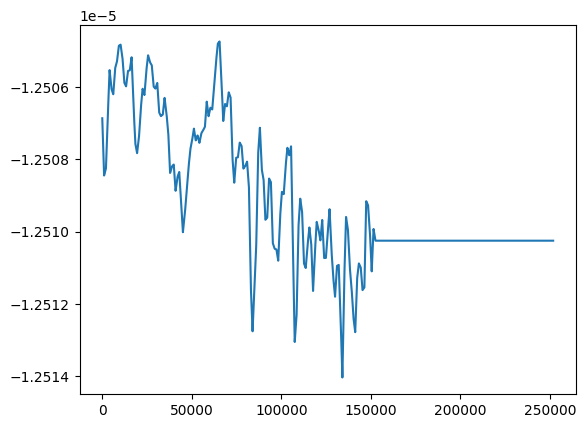

In [ ]:
#=================================================
#make per-spectrum clock delay array for whole of pulse (beware for alignment later)
#=================================================
clock_delay1 = np.interp(np.arange(len(geo_delay1)),np.arange(len(delay_clock_bline))*acclen,delay_clock_bline*1e-9)
plt.plot(clock_delay1)

In [104]:
del spec1_p0
del spec2_p0
del spec1_p1
del spec2_p1

In [187]:
ant1,ant2

(5, 6)

In [188]:
spec1_p0=sky_data[ant1,0,:,:] #pol0
spec2_p0=sky_data[ant2,0,:,:] #pol0
spec1_p1=sky_data[ant1,1,:,:] #pol1
spec2_p1=sky_data[ant2,1,:,:] #pol1

In [164]:
spec1_p0.shape

(251904, 4352)

In [54]:
del sky_data

In [31]:
np.sqrt(1e5*5000)

np.float64(22360.679774997898)

In [179]:
acclen=8000 # 1 row of raw data is roughly 1 ms
st=1000 # start index of raw data
bw=2500 # 1 chan is roughly 1 kHz

In [ ]:
# try all possible sign combinations

Vavg1 = get_vis(spec1_p0, spec1_p1, spec2_p0, spec2_p1, geo_delay2+clock_delay1, acclen)
Vavg1 = np.mean(Vavg1[:,st:st+bw],axis=1)

Vavg2 = get_vis(spec1_p0, spec1_p1, spec2_p0, spec2_p1, -geo_delay2-clock_delay1, acclen)
Vavg2 = np.mean(Vavg1[:,st:st+bw],axis=1)

Vavg3 = get_vis(spec1_p0, spec1_p1, spec2_p0, spec2_p1, -geo_delay2+clock_delay1, acclen)
Vavg3 = np.mean(Vavg1[:,st:st+bw],axis=1)

Vavg4 = get_vis(spec1_p0, spec1_p1, spec2_p0, spec2_p1, geo_delay2-clock_delay1, acclen)
Vavg4 = np.mean(Vavg1[:,st:st+bw],axis=1)

Vavg5 = get_vis(spec1_p0, spec1_p1, spec2_p0, spec2_p1, geo_delay2, acclen)
Vavg5 = np.mean(Vavg1[:,st:st+bw],axis=1)

Vavg6 = get_vis(spec1_p0, spec1_p1, spec2_p0, spec2_p1, -geo_delay2, acclen)
Vavg6 = np.mean(Vavg1[:,st:st+bw],axis=1)

Vavg7 = get_vis(spec1_p0, spec1_p1, spec2_p0, spec2_p1, clock_delay1, acclen)
Vavg7 = np.mean(Vavg1[:,st:st+bw],axis=1)

Vavg8 = get_vis(spec1_p0, spec1_p1, spec2_p0, spec2_p1, -clock_delay1, acclen)
Vavg8 = np.mean(Vavg1[:,st:st+bw],axis=1)

Vavg = get_vis(spec1_p0, spec1_p1, spec2_p0, spec2_p1, np.zeroes(len(clock_delay1)), acclen)
Vavg = np.mean(Vavg1[:,st:st+bw],axis=1)

t = np.arange(Vavg.shape[0])*dt*acclen

plt.plot(t,np.abs(Vavg1), label="clock + geo")
plt.plot(t,np.abs(Vavg2), label="-clock - geo")
plt.plot(t,np.abs(Vavg3), label="clock - geo")
plt.plot(t,np.abs(Vavg4), label="-clock + geo")
plt.plot(t,np.abs(Vavg5), label="geo")
plt.plot(t,np.abs(Vavg6), label="-geo")
plt.plot(t,np.abs(Vavg7), label="clock")
plt.plot(t,np.abs(Vavg8), label="-clock")
plt.plot(t,np.abs(Vavg), label="none")

In [190]:
bw/dt, acclen*dt

(2384185.791015625, 8.388608000000001)

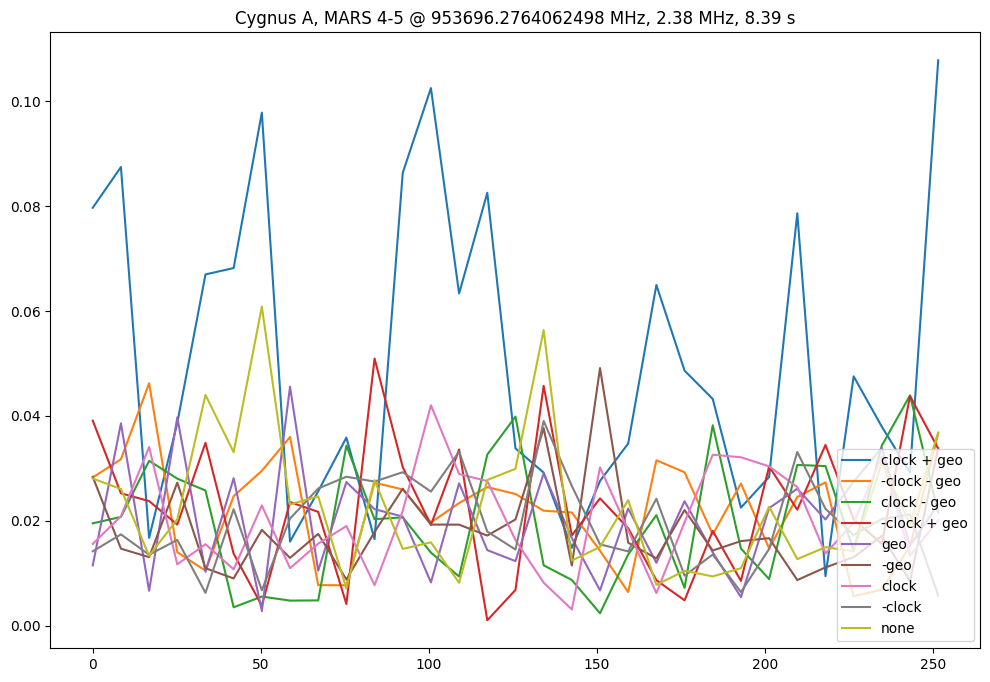

In [ ]:
fig=plt.gcf()
fig.set_size_inches(12,8)
t=np.arange(Vavg.shape[0])*dt*acclen
plt.title(f"Cygnus A, MARS 4-5 @ {360*0.061+st*df} MHz, {bw*df/1e6:4.2f} MHz, {dt*acclen:4.2f} s")
plt.plot(t,np.abs(Vavg1), label="clock + geo")
plt.plot(t,np.abs(Vavg2), label="-clock - geo")
plt.plot(t,np.abs(Vavg3), label="clock - geo")
plt.plot(t,np.abs(Vavg4), label="-clock + geo")
plt.plot(t,np.abs(Vavg5), label="geo")
plt.plot(t,np.abs(Vavg6), label="-geo")
plt.plot(t,np.abs(Vavg7), label="clock")
plt.plot(t,np.abs(Vavg8), label="-clock")
plt.plot(t,np.abs(Vavg), label="none")
plt.legend(loc=4)
#this is clock + geo

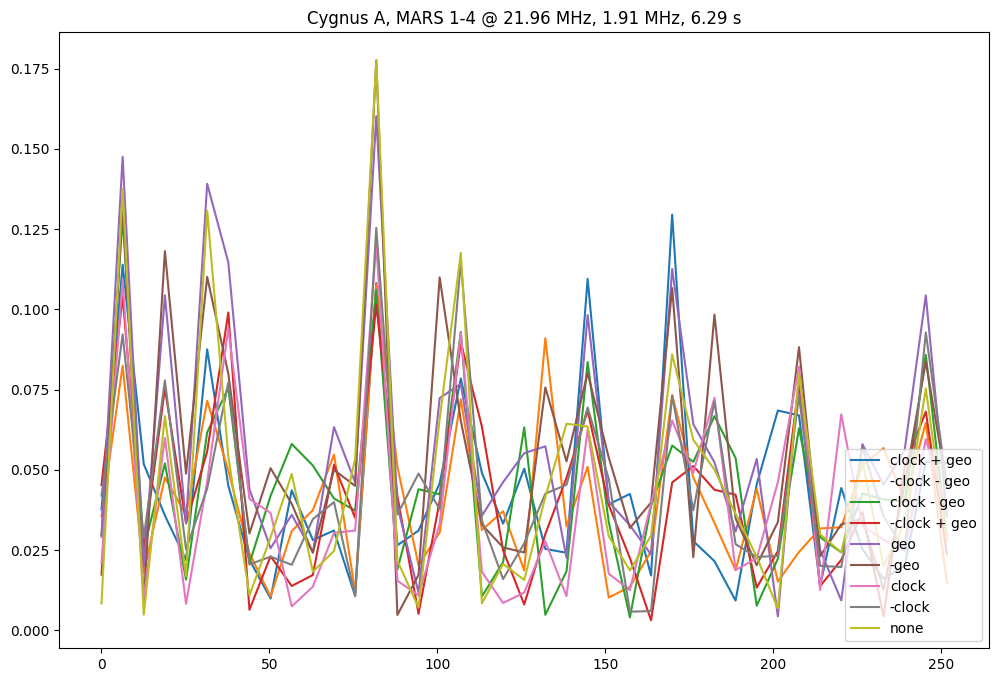

In [98]:
fig=plt.gcf()
fig.set_size_inches(12,8)
t=np.arange(Vavg.shape[0])*dt*acclen
plt.title(f"Cygnus A, MARS 1-4 @ {360*0.061+st*df} MHz, {bw*df/1e6:4.2f} MHz, {dt*acclen:4.2f} s")
plt.plot(t,np.abs(Vavg1), label="clock + geo")
plt.plot(t,np.abs(Vavg2), label="-clock - geo")
plt.plot(t,np.abs(Vavg3), label="clock - geo")
plt.plot(t,np.abs(Vavg4), label="-clock + geo")
plt.plot(t,np.abs(Vavg5), label="geo")
plt.plot(t,np.abs(Vavg6), label="-geo")
plt.plot(t,np.abs(Vavg7), label="clock")
plt.plot(t,np.abs(Vavg8), label="-clock")
plt.plot(t,np.abs(Vavg), label="none")
plt.legend(loc=4)
#this is clock + geo


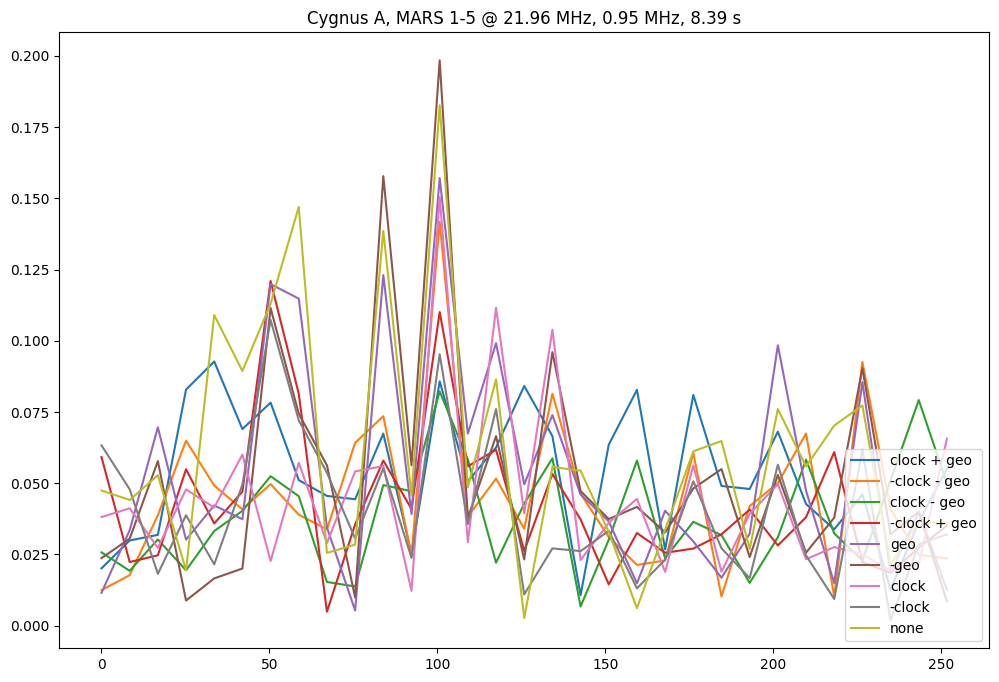

In [76]:
fig=plt.gcf()
fig.set_size_inches(12,8)
t=np.arange(Vavg.shape[0])*dt*acclen
plt.title(f"Cygnus A, MARS 1-5 @ {360*0.061+st*df} MHz, {bw*df/1e6:4.2f} MHz, {dt*acclen:4.2f} s")
plt.plot(t,np.abs(Vavg1), label="clock + geo")
plt.plot(t,np.abs(Vavg2), label="-clock - geo")
plt.plot(t,np.abs(Vavg3), label="clock - geo")
plt.plot(t,np.abs(Vavg4), label="-clock + geo")
plt.plot(t,np.abs(Vavg5), label="geo")
plt.plot(t,np.abs(Vavg6), label="-geo")
plt.plot(t,np.abs(Vavg7), label="clock")
plt.plot(t,np.abs(Vavg8), label="-clock")
plt.plot(t,np.abs(Vavg), label="none")
plt.legend(loc=4)
#this is clock + geo


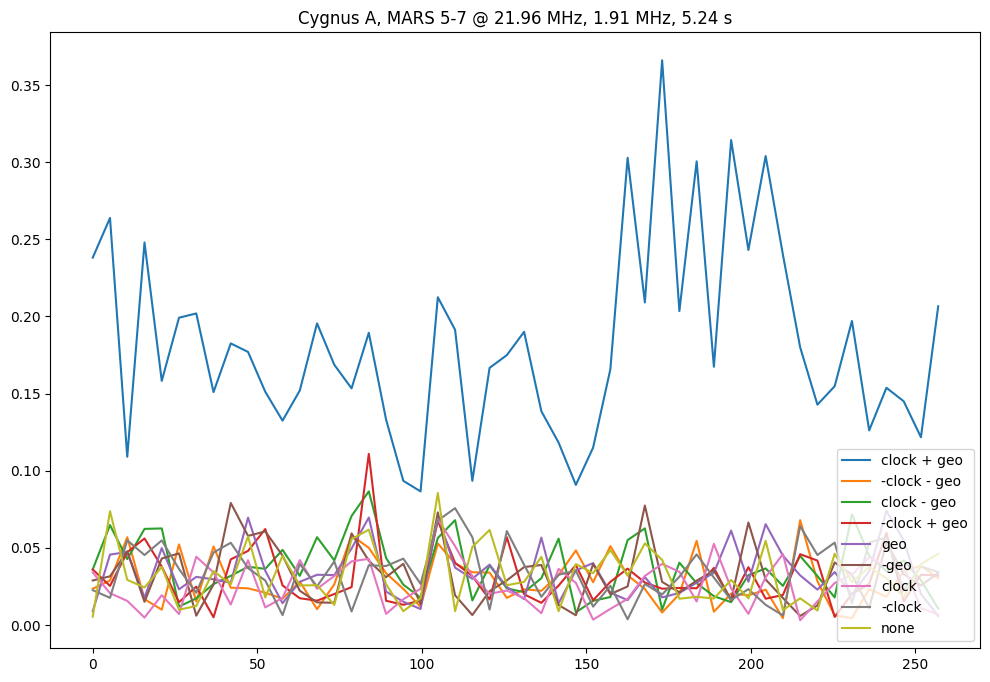

In [46]:
fig=plt.gcf()
fig.set_size_inches(12,8)
t=np.arange(Vavg.shape[0])*dt*acclen
plt.title(f"Cygnus A, MARS 5-7 @ {360*0.061+st*df} MHz, {bw*df/1e6:4.2f} MHz, {dt*acclen:4.2f} s")
plt.plot(t,np.abs(Vavg1), label="clock + geo")
plt.plot(t,np.abs(Vavg2), label="-clock - geo")
plt.plot(t,np.abs(Vavg3), label="clock - geo")
plt.plot(t,np.abs(Vavg4), label="-clock + geo")
plt.plot(t,np.abs(Vavg5), label="geo")
plt.plot(t,np.abs(Vavg6), label="-geo")
plt.plot(t,np.abs(Vavg7), label="clock")
plt.plot(t,np.abs(Vavg8), label="-clock")
plt.plot(t,np.abs(Vavg), label="none")
plt.legend(loc=4)
#this is clock + geo


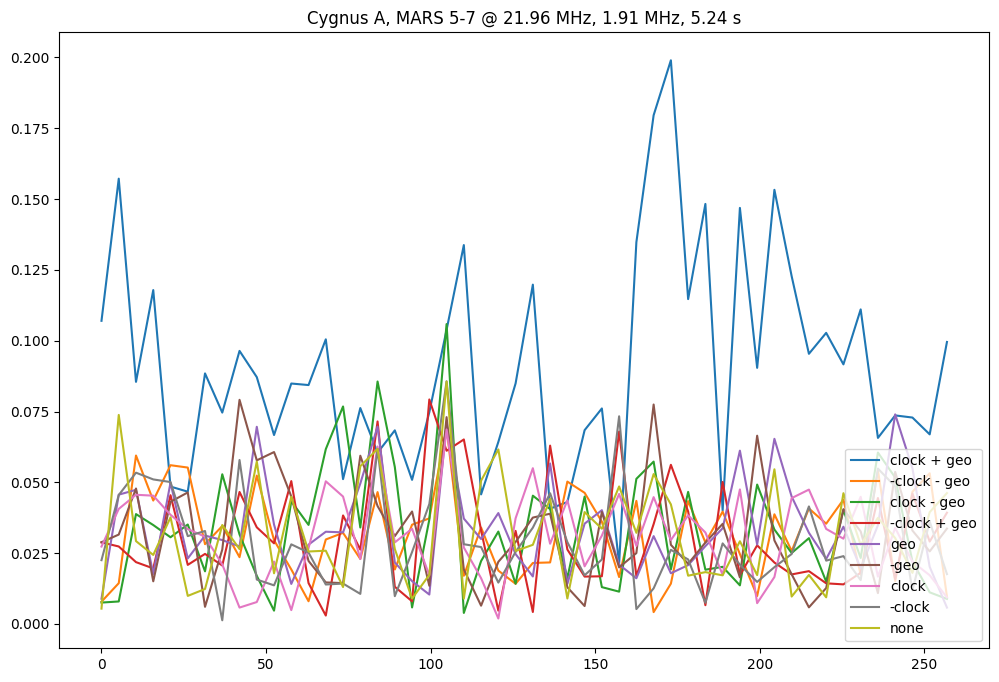

In [70]:
fig=plt.gcf()
fig.set_size_inches(12,8)
t=np.arange(Vavg.shape[0])*dt*acclen
plt.title(f"Cygnus A, MARS 5-7 @ {360*0.061+st*df} MHz, {bw*df/1e6:4.2f} MHz, {dt*acclen:4.2f} s")
plt.plot(t,np.abs(Vavg1), label="clock + geo")
plt.plot(t,np.abs(Vavg2), label="-clock - geo")
plt.plot(t,np.abs(Vavg3), label="clock - geo")
plt.plot(t,np.abs(Vavg4), label="-clock + geo")
plt.plot(t,np.abs(Vavg5), label="geo")
plt.plot(t,np.abs(Vavg6), label="-geo")
plt.plot(t,np.abs(Vavg7), label="clock")
plt.plot(t,np.abs(Vavg8), label="-clock")
plt.plot(t,np.abs(Vavg), label="none")
plt.legend(loc=4)
#this is clock + geo


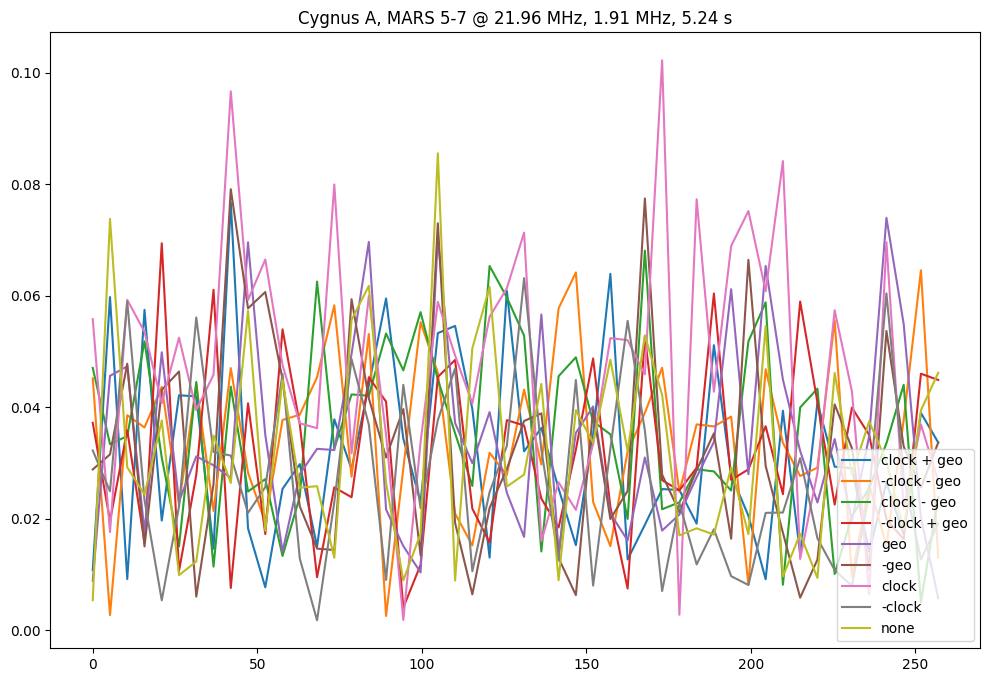

In [76]:
fig=plt.gcf()
fig.set_size_inches(12,8)
t=np.arange(Vavg.shape[0])*dt*acclen
plt.title(f"Cygnus A, MARS 5-7 @ {360*0.061+st*df} MHz, {bw*df/1e6:4.2f} MHz, {dt*acclen:4.2f} s")
plt.plot(t,np.abs(Vavg1), label="clock + geo")
plt.plot(t,np.abs(Vavg2), label="-clock - geo")
plt.plot(t,np.abs(Vavg3), label="clock - geo")
plt.plot(t,np.abs(Vavg4), label="-clock + geo")
plt.plot(t,np.abs(Vavg5), label="geo")
plt.plot(t,np.abs(Vavg6), label="-geo")
plt.plot(t,np.abs(Vavg7), label="clock")
plt.plot(t,np.abs(Vavg8), label="-clock")
plt.plot(t,np.abs(Vavg), label="none")
plt.legend(loc=4)
#this is clock + geo


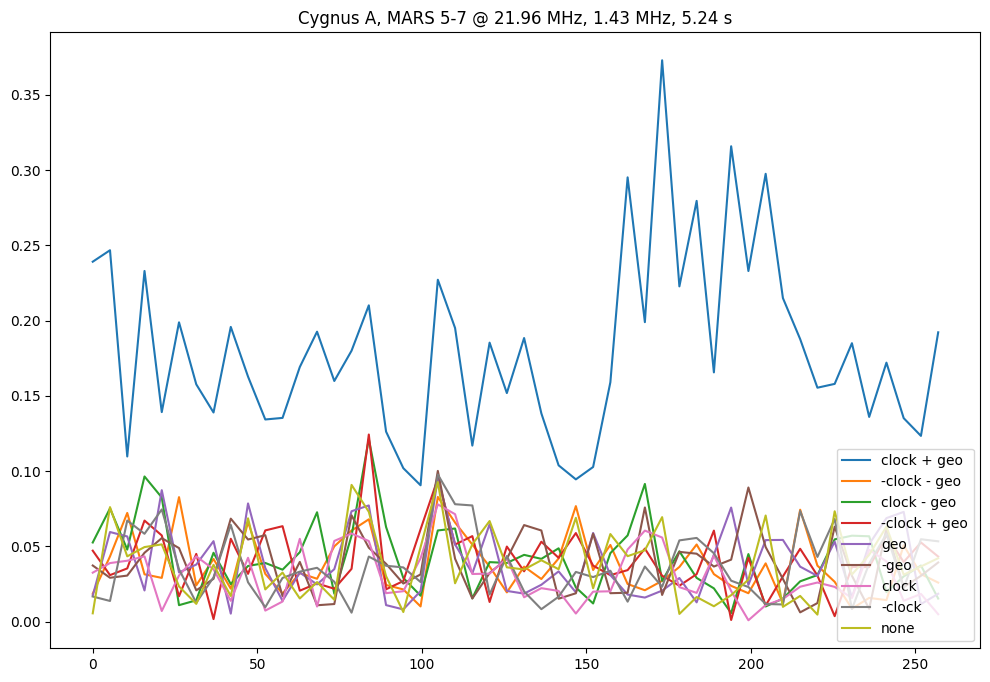

In [172]:
fig=plt.gcf()
fig.set_size_inches(12,8)
t=np.arange(Vavg.shape[0])*dt*acclen
plt.title(f"Cygnus A, MARS 5-7 @ {360*0.061+st*df} MHz, {bw*df/1e6:4.2f} MHz, {dt*acclen:4.2f} s")
plt.plot(t,np.abs(Vavg1), label="clock + geo")
plt.plot(t,np.abs(Vavg2), label="-clock - geo")
plt.plot(t,np.abs(Vavg3), label="clock - geo")
plt.plot(t,np.abs(Vavg4), label="-clock + geo")
plt.plot(t,np.abs(Vavg5), label="geo")
plt.plot(t,np.abs(Vavg6), label="-geo")
plt.plot(t,np.abs(Vavg7), label="clock")
plt.plot(t,np.abs(Vavg8), label="-clock")
plt.plot(t,np.abs(Vavg), label="none")
plt.legend(loc=4)
#this is clock + geo


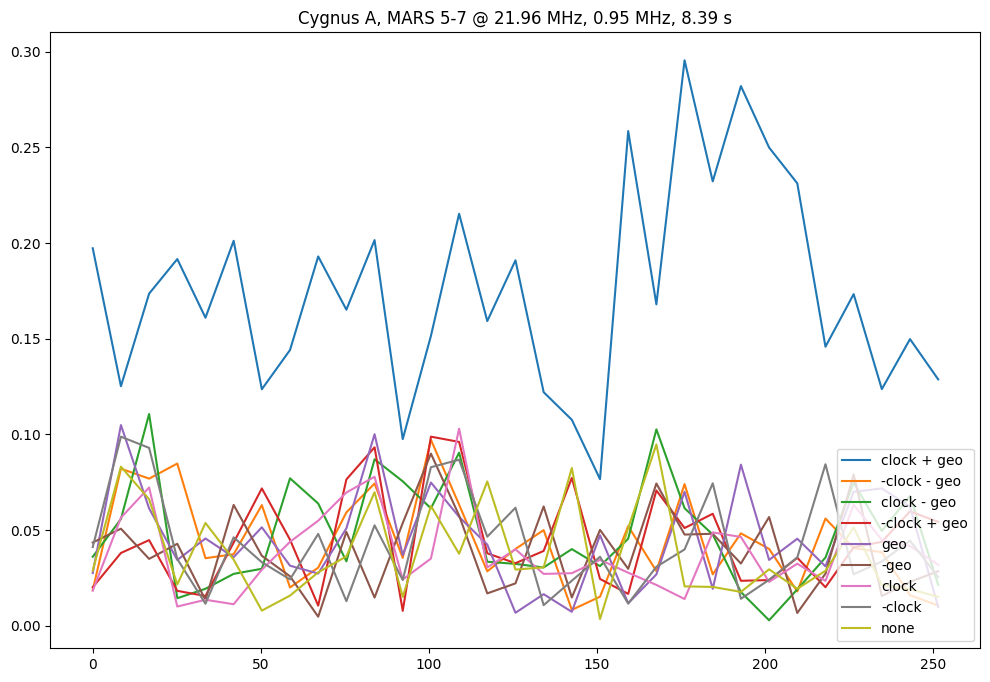

In [178]:
fig=plt.gcf()
fig.set_size_inches(12,8)
t=np.arange(Vavg.shape[0])*dt*acclen
plt.title(f"Cygnus A, MARS 5-7 @ {360*0.061+st*df} MHz, {bw*df/1e6:4.2f} MHz, {dt*acclen:4.2f} s")
plt.plot(t,np.abs(Vavg1), label="clock + geo")
plt.plot(t,np.abs(Vavg2), label="-clock - geo")
plt.plot(t,np.abs(Vavg3), label="clock - geo")
plt.plot(t,np.abs(Vavg4), label="-clock + geo")
plt.plot(t,np.abs(Vavg5), label="geo")
plt.plot(t,np.abs(Vavg6), label="-geo")
plt.plot(t,np.abs(Vavg7), label="clock")
plt.plot(t,np.abs(Vavg8), label="-clock")
plt.plot(t,np.abs(Vavg), label="none")
plt.legend(loc=4)
#this is clock + geo


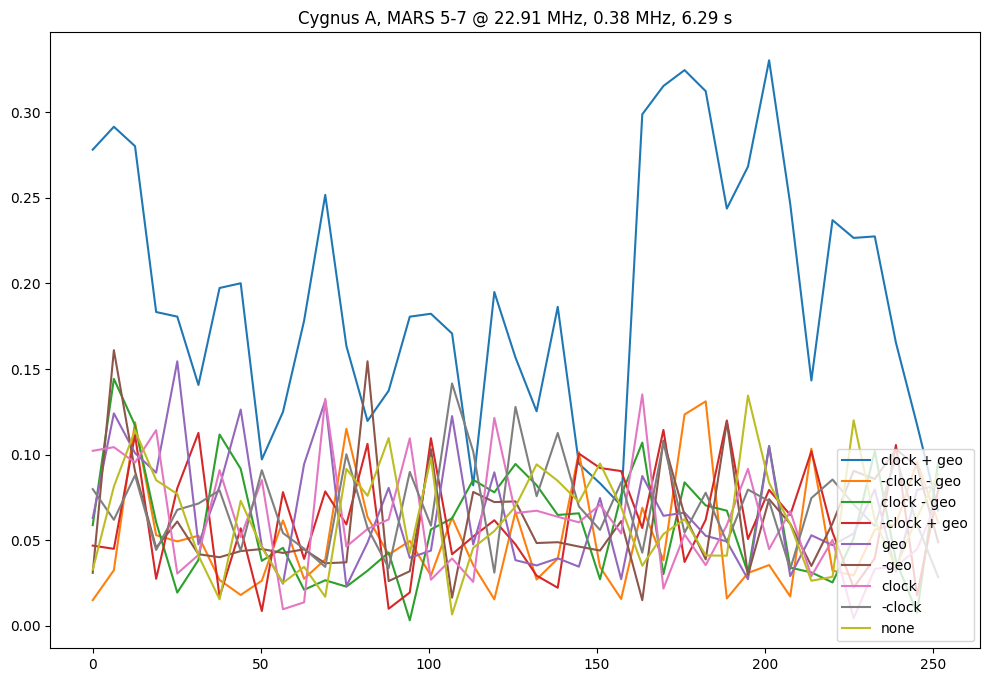

In [37]:
fig=plt.gcf()
fig.set_size_inches(12,8)
t=np.arange(Vavg.shape[0])*dt*acclen
plt.title(f"Cygnus A, MARS 5-7 @ {360*0.061+st*df/1e6:4.2f} MHz, {bw*df/1e6:4.2f} MHz, {dt*acclen:4.2f} s")
plt.plot(t,np.abs(Vavg1), label="clock + geo")
plt.plot(t,np.abs(Vavg2), label="-clock - geo")
plt.plot(t,np.abs(Vavg3), label="clock - geo")
plt.plot(t,np.abs(Vavg4), label="-clock + geo")
plt.plot(t,np.abs(Vavg5), label="geo")
plt.plot(t,np.abs(Vavg6), label="-geo")
plt.plot(t,np.abs(Vavg7), label="clock")
plt.plot(t,np.abs(Vavg8), label="-clock")
plt.plot(t,np.abs(Vavg), label="none")
plt.legend(loc=4)
#this is clock + geo


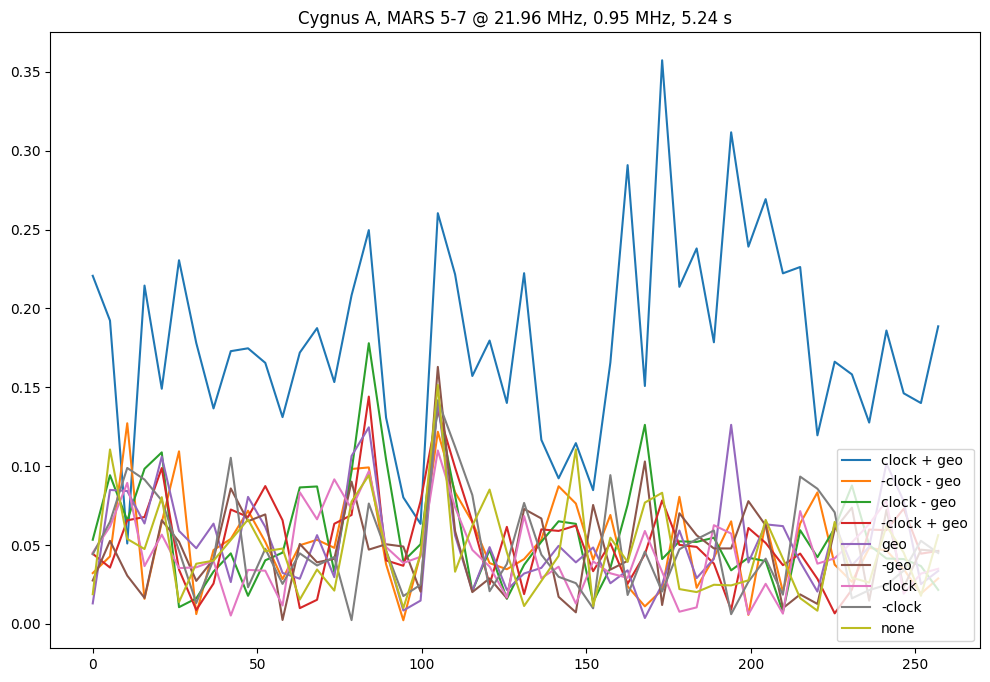

In [24]:
fig=plt.gcf()
fig.set_size_inches(12,8)
t=np.arange(Vavg.shape[0])*dt*acclen
plt.title(f"Cygnus A, MARS 5-7 @ {360*0.061+st*df} MHz, {bw*df/1e6:4.2f} MHz, {dt*acclen:4.2f} s")
plt.plot(t,np.abs(Vavg1), label="clock + geo")
plt.plot(t,np.abs(Vavg2), label="-clock - geo")
plt.plot(t,np.abs(Vavg3), label="clock - geo")
plt.plot(t,np.abs(Vavg4), label="-clock + geo")
plt.plot(t,np.abs(Vavg5), label="geo")
plt.plot(t,np.abs(Vavg6), label="-geo")
plt.plot(t,np.abs(Vavg7), label="clock")
plt.plot(t,np.abs(Vavg8), label="-clock")
plt.plot(t,np.abs(Vavg), label="none")
plt.legend(loc=4)
#this is clock + geo


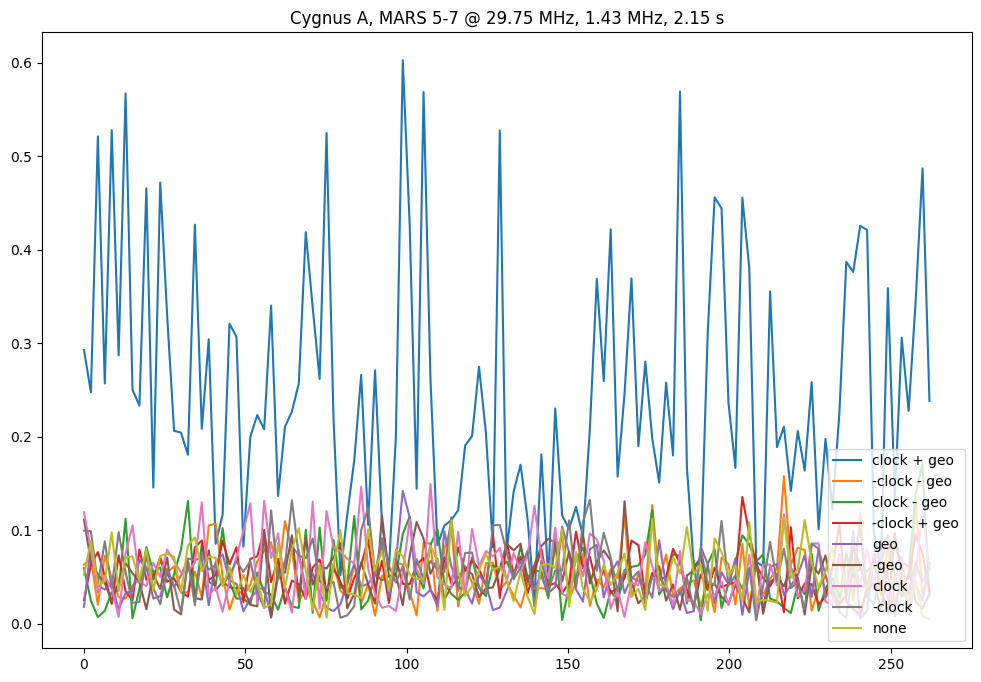

In [69]:
fig=plt.gcf()
fig.set_size_inches(12,8)
t=np.arange(Vavg.shape[0])*dt*acclen
plt.title(f"Cygnus A, MARS 5-7 @ {472*0.061+st*df/1e6:4.2f} MHz, {bw*df/1e6:4.2f} MHz, {dt*acclen:4.2f} s")
plt.plot(t,np.abs(Vavg1), label="clock + geo")
plt.plot(t,np.abs(Vavg2), label="-clock - geo")
plt.plot(t,np.abs(Vavg3), label="clock - geo")
plt.plot(t,np.abs(Vavg4), label="-clock + geo")
plt.plot(t,np.abs(Vavg5), label="geo")
plt.plot(t,np.abs(Vavg6), label="-geo")
plt.plot(t,np.abs(Vavg7), label="clock")
plt.plot(t,np.abs(Vavg8), label="-clock")
plt.plot(t,np.abs(Vavg), label="none")
plt.legend(loc=4)
#this is clock + geo


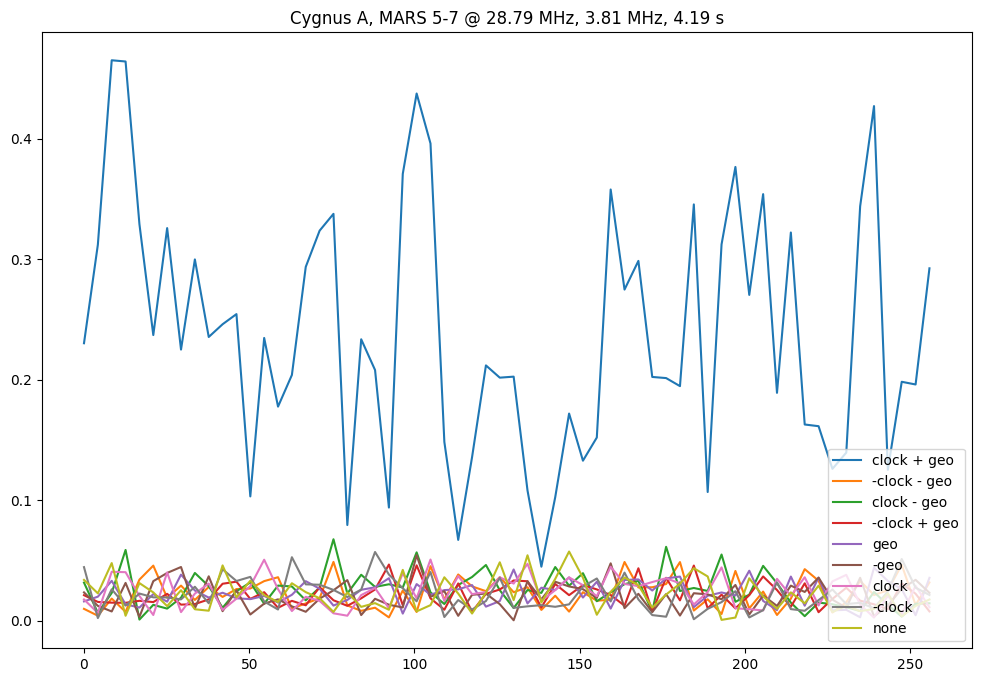

In [75]:
fig=plt.gcf()
fig.set_size_inches(12,8)
t=np.arange(Vavg.shape[0])*dt*acclen
plt.title(f"Cygnus A, MARS 5-7 @ {472*0.061+st*df/1e6:4.2f} MHz, {bw*df/1e6:4.2f} MHz, {dt*acclen:4.2f} s")
plt.plot(t,np.abs(Vavg1), label="clock + geo")
plt.plot(t,np.abs(Vavg2), label="-clock - geo")
plt.plot(t,np.abs(Vavg3), label="clock - geo")
plt.plot(t,np.abs(Vavg4), label="-clock + geo")
plt.plot(t,np.abs(Vavg5), label="geo")
plt.plot(t,np.abs(Vavg6), label="-geo")
plt.plot(t,np.abs(Vavg7), label="clock")
plt.plot(t,np.abs(Vavg8), label="-clock")
plt.plot(t,np.abs(Vavg), label="none")
plt.legend(loc=4)
#this is clock + geo


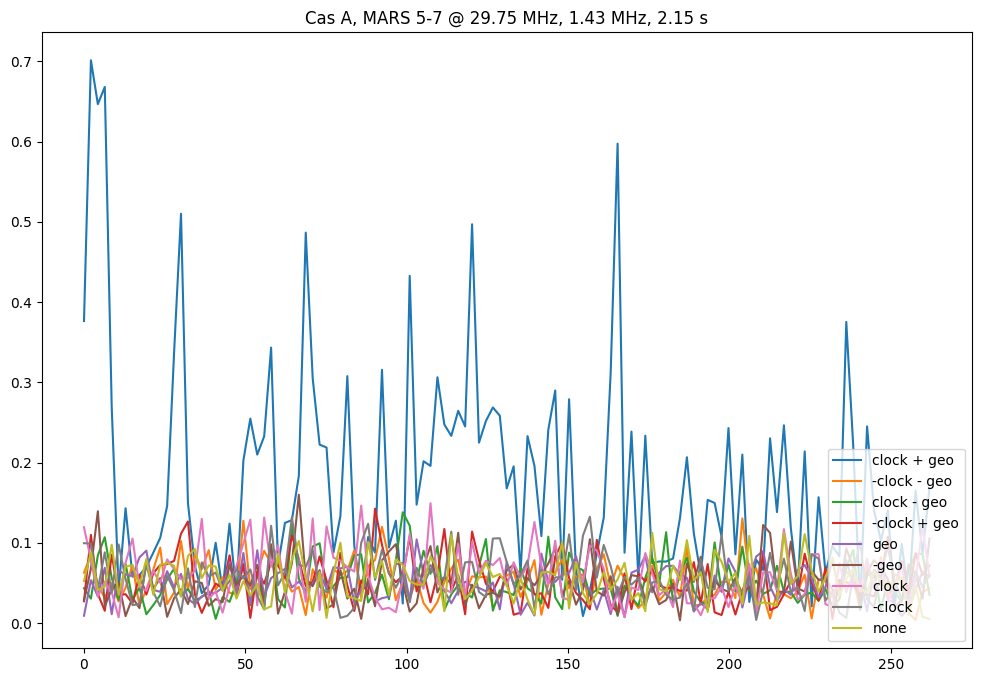

In [71]:
fig=plt.gcf()
fig.set_size_inches(12,8)
t=np.arange(Vavg.shape[0])*dt*acclen
plt.title(f"Cas A, MARS 5-7 @ {472*0.061+st*df/1e6:4.2f} MHz, {bw*df/1e6:4.2f} MHz, {dt*acclen:4.2f} s")
plt.plot(t,np.abs(Vavg1), label="clock + geo")
plt.plot(t,np.abs(Vavg2), label="-clock - geo")
plt.plot(t,np.abs(Vavg3), label="clock - geo")
plt.plot(t,np.abs(Vavg4), label="-clock + geo")
plt.plot(t,np.abs(Vavg5), label="geo")
plt.plot(t,np.abs(Vavg6), label="-geo")
plt.plot(t,np.abs(Vavg7), label="clock")
plt.plot(t,np.abs(Vavg8), label="-clock")
plt.plot(t,np.abs(Vavg), label="none")
plt.legend(loc=4)
#this is clock + geo


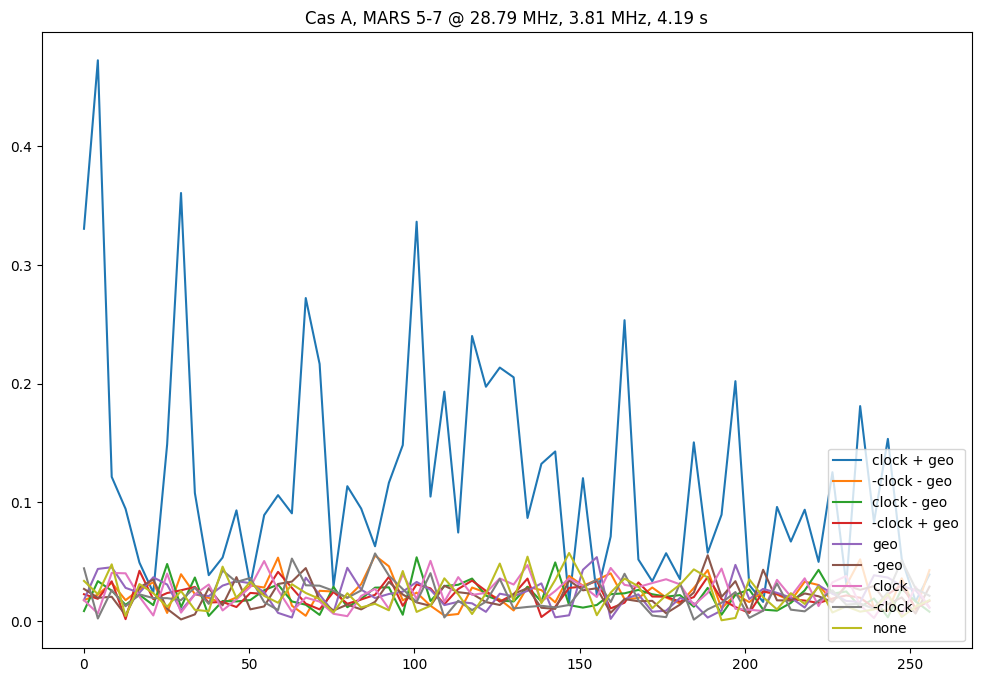

In [73]:
fig=plt.gcf()
fig.set_size_inches(12,8)
t=np.arange(Vavg.shape[0])*dt*acclen
plt.title(f"Cas A, MARS 5-7 @ {472*0.061+st*df/1e6:4.2f} MHz, {bw*df/1e6:4.2f} MHz, {dt*acclen:4.2f} s")
plt.plot(t,np.abs(Vavg1), label="clock + geo")
plt.plot(t,np.abs(Vavg2), label="-clock - geo")
plt.plot(t,np.abs(Vavg3), label="clock - geo")
plt.plot(t,np.abs(Vavg4), label="-clock + geo")
plt.plot(t,np.abs(Vavg5), label="geo")
plt.plot(t,np.abs(Vavg6), label="-geo")
plt.plot(t,np.abs(Vavg7), label="clock")
plt.plot(t,np.abs(Vavg8), label="-clock")
plt.plot(t,np.abs(Vavg), label="none")
plt.legend(loc=4)
#this is clock + geo


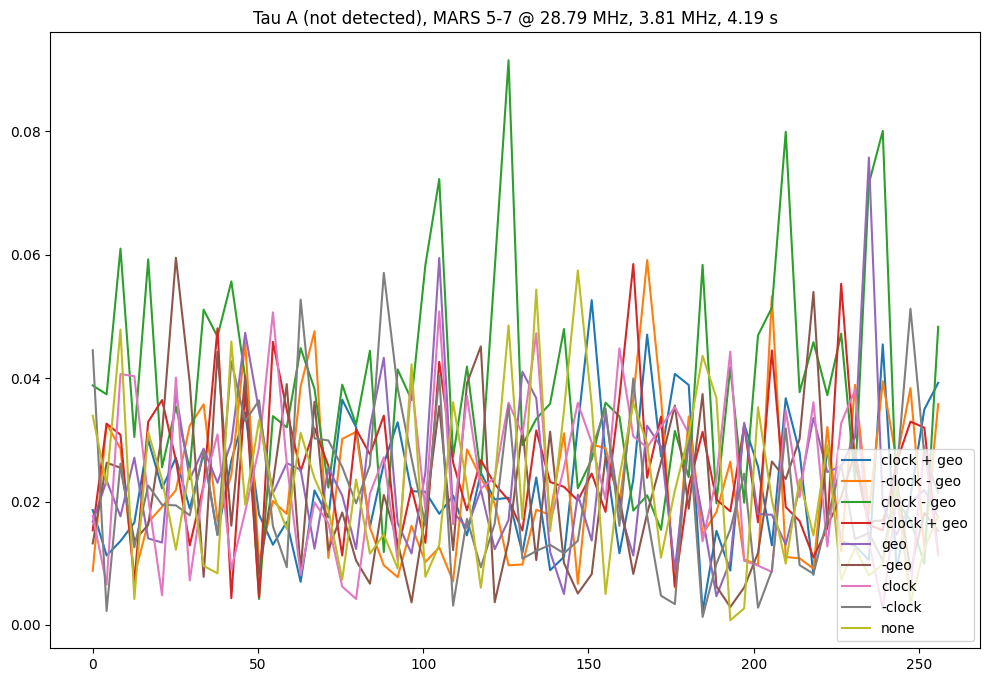

In [80]:
fig=plt.gcf()
fig.set_size_inches(12,8)
t=np.arange(Vavg.shape[0])*dt*acclen
plt.title(f"Tau A (not detected), MARS 5-7 @ {472*0.061+st*df/1e6:4.2f} MHz, {bw*df/1e6:4.2f} MHz, {dt*acclen:4.2f} s")
plt.plot(t,np.abs(Vavg1), label="clock + geo")
plt.plot(t,np.abs(Vavg2), label="-clock - geo")
plt.plot(t,np.abs(Vavg3), label="clock - geo")
plt.plot(t,np.abs(Vavg4), label="-clock + geo")
plt.plot(t,np.abs(Vavg5), label="geo")
plt.plot(t,np.abs(Vavg6), label="-geo")
plt.plot(t,np.abs(Vavg7), label="clock")
plt.plot(t,np.abs(Vavg8), label="-clock")
plt.plot(t,np.abs(Vavg), label="none")
plt.legend(loc=4)
#this is clock + geo


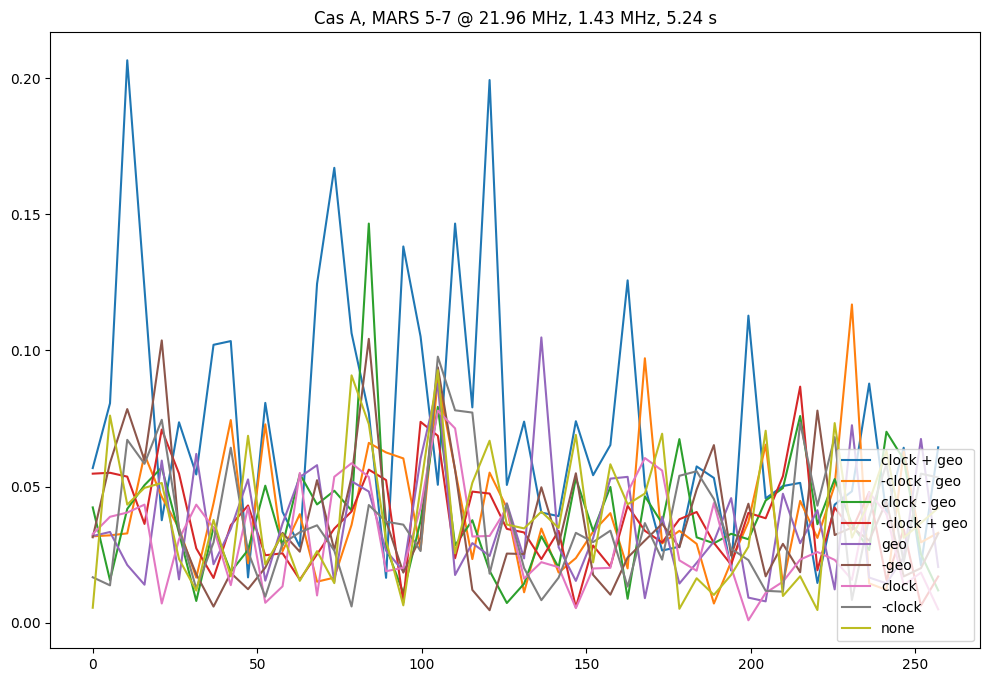

In [125]:
fig=plt.gcf()
fig.set_size_inches(12,8)
t=np.arange(Vavg.shape[0])*dt*acclen
plt.title(f"Cas A, MARS 5-7 @ {360*0.061+st*df} MHz, {bw*df/1e6:4.2f} MHz, {dt*acclen:4.2f} s")
plt.plot(t,np.abs(Vavg1), label="clock + geo")
plt.plot(t,np.abs(Vavg2), label="-clock - geo")
plt.plot(t,np.abs(Vavg3), label="clock - geo")
plt.plot(t,np.abs(Vavg4), label="-clock + geo")
plt.plot(t,np.abs(Vavg5), label="geo")
plt.plot(t,np.abs(Vavg6), label="-geo")
plt.plot(t,np.abs(Vavg7), label="clock")
plt.plot(t,np.abs(Vavg8), label="-clock")
plt.plot(t,np.abs(Vavg), label="none")
plt.legend(loc=4)
#this is clock + geo


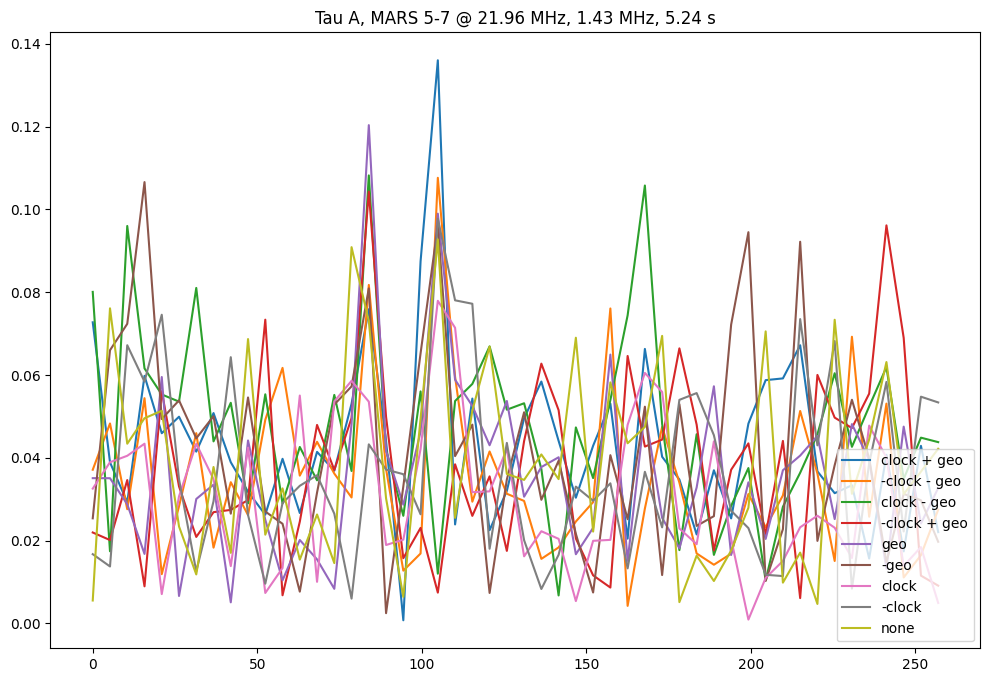

In [133]:
fig=plt.gcf()
fig.set_size_inches(12,8)
t=np.arange(Vavg.shape[0])*dt*acclen
plt.title(f"Tau A, MARS 5-7 @ {360*0.061+st*df} MHz, {bw*df/1e6:4.2f} MHz, {dt*acclen:4.2f} s")
plt.plot(t,np.abs(Vavg1), label="clock + geo")
plt.plot(t,np.abs(Vavg2), label="-clock - geo")
plt.plot(t,np.abs(Vavg3), label="clock - geo")
plt.plot(t,np.abs(Vavg4), label="-clock + geo")
plt.plot(t,np.abs(Vavg5), label="geo")
plt.plot(t,np.abs(Vavg6), label="-geo")
plt.plot(t,np.abs(Vavg7), label="clock")
plt.plot(t,np.abs(Vavg8), label="-clock")
plt.plot(t,np.abs(Vavg), label="none")
plt.legend(loc=4)
#this is clock + geo


In [116]:
np.rad2deg((3e8/22e6)/np.sqrt(bl@bl))

np.float64(0.8194554595879955)